In [1]:
# import dependencies
import RMF
import IMP.npctransport
import pickle
import numpy as np
import os
import multiprocessing as mp
from functools import partial

In [2]:
def _has_depth_with_site(root, i):
    """ returns true if node subtree thru first child is at least i
        levels, including the root node itself, and the lead is a site """
#  print root, i, len(root.get_children())
    if (i==1) and root.get_name()=="site":
        return True
    c = root.get_children()
    if len(c) == 0:
        return False
    return _has_depth_with_site(c[0], i-1)

def _add_nodes(node, tf, type_prefixes, depth=0):
    '''
    node - rmf node to scan
    tf - typed factory
    type_prefixes - list of full type prefixes (e.g. "Nup1" for "Nup1N")

    adds only nodes whose type name begins with any of the specified type prefixes
    '''
    children = node.get_children()
    ret = []
    if len(children)==0:
        return ret
    if _has_depth_with_site(node, 3) and tf.get_is(children[0]):
        child_type = tf.get(children[0]).get_type_name()
        if any([child_type.startswith(tp) for tp in type_prefixes]):
            ret.append(children)
    for c in children:
        ret += _add_nodes(c, tf,  type_prefixes, depth+1)
    return ret

def _add_nodes_exact(node, tf, types, depth=0):
    '''
    node - rmf node to scan
    tf - typed factory
    types - list of full types (e.g. "Nup1N")

    adds only nodes whose type name begins with any of the specified type prefixes
    '''
    children = node.get_children()
    ret = []
    if len(children)==0:
        return ret
    if _has_depth_with_site(node, 3) and tf.get_is(children[0]):
        child_type = tf.get(children[0]).get_type_name()
        if any([child_type == tp for tp in types]):
            ret.append(children)
    for c in children:
        ret += _add_nodes_exact(c, tf,  types, depth+1)
    return ret

def get_trajectories_shape(n_molecules, start_t, end_t, step_t, frames_per_file):
    return [n_molecules, 3, int(((end_t - start_t) / step_t) * frames_per_file)]

def load_kap_data(input_rmf_path, kap_radius, kap_amount, start_t, end_t, step_t, frames_per_file=104, one_frame_from_each=False):
    trajectories_shape = [kap_amount, 3, int(((end_t - start_t) / step_t) * frames_per_file)]
    trajectories = np.zeros(shape=trajectories_shape)

    for rmf_t in range(start_t, end_t, step_t):
        in_fh = RMF.open_rmf_file_read_only(f"{input_rmf_path}/{rmf_t}.movie.rmf")
        rff = RMF.ReferenceFrameFactory(in_fh)
        tf = RMF.TypedFactory(in_fh)
        kap_types = [f"kap{kap_radius}"]

        # load data
        type2chains={}
        for i, kap_type in enumerate(kap_types):
            type2chains[kap_type] = _add_nodes(in_fh.get_root_node(), tf, [kap_type])
            
        # set frame
        for f_id, f in enumerate(in_fh.get_frames()):
            in_fh.set_current_frame(f)
    
            traj_i = int(f_id + ((rmf_t - start_t) / step_t) * frames_per_file)
            # read data
            for kap_i in range(kap_amount):
                coord = rff.get(type2chains["kap35"][0][kap_i]).get_translation()
                
                trajectories[kap_i, 0, traj_i] = coord[0] / 10
                trajectories[kap_i, 1, traj_i] = coord[1] / 10
                trajectories[kap_i, 2, traj_i] = coord[2] / 10
            if one_frame_from_each:
                break
    return trajectories

def load_fg_data(input_rmf_path, fg_types, n_chains_per_fg, n_beads_per_fg, start_t, end_t, step_t, frames_per_file=104, one_frame_from_each=False):
    trajectories = dict()
    for i, fg_type in enumerate(fg_types):
        shape = [n_chains_per_fg[i], n_beads_per_fg[i], 3, int(((end_t - start_t) / step_t) * frames_per_file)]
        trajectories[fg_type] = np.zeros(shape=shape)

    for rmf_t in range(start_t, end_t, step_t):
        in_fh = RMF.open_rmf_file_read_only(f"{input_rmf_path}/{rmf_t}.movie.rmf")
        rff = RMF.ReferenceFrameFactory(in_fh)
        tf = RMF.TypedFactory(in_fh)
        type2chains={}
        for i, fg in enumerate(fg_types):
            type2chains[fg] = _add_nodes(in_fh.get_root_node(), tf, [fg + "anchor", fg + "s", fg + "C", fg + "N", fg + "m"])
            
        for f_id, f in enumerate(in_fh.get_frames()):
            # set frame
            in_fh.set_current_frame(f)
    
            traj_i = int(f_id + ((rmf_t - start_t) / step_t) * frames_per_file)
            # read data
            for nup_i, fg_type in enumerate(fg_types):
                for chain_i in range(n_chains_per_fg[nup_i]):
                    for bead_i in range(n_beads_per_fg[nup_i]):
                        coord = rff.get(type2chains[fg_type][chain_i][bead_i]).get_translation()
                        trajectories[fg_type][chain_i, bead_i, 0, traj_i] = coord[0] / 10
                        trajectories[fg_type][chain_i, bead_i, 1, traj_i] = coord[1] / 10
                        trajectories[fg_type][chain_i, bead_i, 2, traj_i] = coord[2] / 10
            if one_frame_from_each:
                break
    return trajectories    

## NTRs
Reads data from NPC simulations and saves trajectories for each NTR.

In general, pickles generated by this script contain numpy arrays with the shape:

[kap_amount, 3, n_frames]

In [27]:
trajectories = load_kap_data(
          input_rmf_path="/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/2/",
          kap_radius=35,
          kap_amount=250,
          start_t=40000,
          end_t=80000,
          step_t=100,
          frames_per_file=1,
          one_frame_from_each=True)
with open("spatial_markov_chain_data.pickle", "wb") as f:
    pickle.dump(trajectories, f)

In [13]:
kap_amount = 250
start_t = 210000
end_t = 220000
step_t = 100
frames_per_file = 1
sims_range = range(1, 31)
load_path = "/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/mutations/no-nup116/"
save_path = "data/mutations/no-nup116/singles/"

bad_sims = []
for i in sims_range:
    # check that trajectory reached end_t time
    if not os.path.isfile(f"{load_path}/{i}/{end_t}.movie.rmf"):
        print(f"sim {i} not long enough")
        bad_sims.append(i)
        continue

def process_simulation(i, kap_amount, start_t, end_t, step_t, frames_per_file, one_frame_from_each):
    print(f"{i} ", end="")
    trajectories = load_kap_data(
          input_rmf_path=f"{load_path}/{i}",
          kap_radius=35,
          kap_amount=kap_amount,
          start_t=start_t,
          end_t=end_t,
          step_t=step_t,
          frames_per_file=frames_per_file,
          one_frame_from_each=True)
    if not os.path.exists(f"{save_path}/{i}"):
        os.makedirs(f"{save_path}/{i}")
    with open(f"{save_path}/{i}/{int(start_t/1000)}-{int(end_t/1000)}.pickle", "wb") as f:
        pickle.dump(trajectories, f)


process_sim_partial = partial(
        process_simulation,
        kap_amount=kap_amount,
        start_t=start_t,
        end_t=end_t,
        step_t=step_t,
        frames_per_file=frames_per_file,
        one_frame_from_each=True
    )

# Use all available CPU cores
num_processes = len(os.sched_getaffinity(0))
print(f"Number of cpus: {num_processes}")

# Create a pool of workers
good_sims = [i for i in sims_range if i not in bad_sims]
with mp.Pool(processes=num_processes) as pool:
    # Map the processing function to all good simulations
    pool.map(process_sim_partial, good_sims)

sim 25 not long enough
sim 26 not long enough
sim 27 not long enough
sim 28 not long enough
sim 29 not long enough
sim 30 not long enough
Number of cpus: 30
4 7 3 1 6 5 9 2 11 8 10 14 13 23 17 15 18 20 12 16 19 24 21 22 

In [10]:
# Merge singles into merged

arrays = []
for i in range(1, 51):
    with open(f"data/singles/{i}/130-140.pickle", "rb") as f:
        arrays.append(pickle.load(f))
trajectories = np.concatenate(arrays, axis=0)
with open(f"data/merged/130-140.pickle", "wb") as f:
    pickle.dump(trajectories, f)

In [11]:
# Merge merged

arrays = []
for i in ["110-130", "130-140", "140-150", "150-160"]:
    with open(f"data/merged/{i}.pickle", "rb") as f:
        arrays.append(pickle.load(f))
trajectories = np.concatenate(arrays, axis=2)
with open(f"data/merged/110-160.pickle", "wb") as f:
    pickle.dump(trajectories, f)

In [3]:
# Merge times

for j in range(1, 51):
    arrays = []
    for i in ["150-160", "160-170", "170-180"]:
        with open(f"data/singles/{j}/{i}.pickle", "rb") as f:
            arrays.append(pickle.load(f))
    trajectories = np.concatenate(arrays, axis=2)
    with open(f"data/singles/{j}/150-180.pickle", "wb") as f:
        pickle.dump(trajectories, f)

In [4]:
# save data for 30-40 us 

kap_amount = 250
start_t = 30000
end_t = 40000
step_t = 100
frames_per_file = 1

trajectories = load_kap_data(
        input_rmf_path=f"/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/2/",
        kap_radius=35,
        kap_amount=kap_amount,
        start_t=start_t,
        end_t=end_t,
        step_t=step_t,
        frames_per_file=frames_per_file,
        one_frame_from_each=True)
with open(f"data/other/30-40.pickle", "wb") as f:
    pickle.dump(trajectories, f)

## FGs

Reads data from NPC simulations and saves trajectories for each NUP.

In general, pickles generated by this script contain the following structures:

Dictionary(nup_type : np.array([chains, beads, 3, n_frames]))

```
Nup2: 16 chains, each has 20 beads
Nsp1: 48 chains, each has 32 beads
Nup100: 16 chains, each has 40 beads
Nup116: 16 chains, each has 48 beads
Nup159: 16 chains, each has 34 beads
Nup49: 32 chains, each has 14 beads
Nup57: 32 chains, each has 15 beads
Nup145: 16 chains, each has 13 beads
Nup1: 8 chains, each has 44 beads
Nup60: 16 chains, each has 12 beads

Total: 216 Chains, ? Beads
```


Anchor coordinates are saved in the format:

Dictionary (str(<fg_type>_<chain_i>) : np.array([3])])

In [ ]:
# fg_types = ['Nup2', 'Nsp1', 'Nup100', 'Nup116', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60']
# n_chains_per_fg = [16, 48, 16, 16, 16, 32, 32, 16, 8, 16]
# n_beads_per_fg = [20, 32, 40, 48, 34, 14, 15, 13, 44, 12]

fg_types = ['Nup2', 'Nup100', 'Nup116', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60']
n_chains_per_fg = [16, 16, 16, 16, 32, 32, 16, 8, 16]
n_beads_per_fg = [20, 40, 48, 34, 14, 15, 13, 44, 12]

fg_types = ['Nup2', 'Nsp1', 'Nup116', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60']
n_chains_per_fg = [16, 48, 16, 16, 32, 32, 16, 8, 16]
n_beads_per_fg = [20, 32, 48, 34, 14, 15, 13, 44, 12]

fg_types = ['Nup2', 'Nsp1', 'Nup100', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60']
n_chains_per_fg = [16, 48, 16, 16, 32, 32, 16, 8, 16]
n_beads_per_fg = [20, 32, 40, 34, 14, 15, 13, 44, 12]


start_t = 210000
end_t = 220000
step_t = 100
frames_per_file = 1
sims_range = range(1, 31)
load_path = "/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/mutations/no-nup100/"
save_path = "data/mutations/no-nup100/singles/"

bad_sims = []
for i in sims_range:
    # check that trajectory reached end_t time
    if not os.path.isfile(f"{load_path}/{i}/{end_t}.movie.rmf"):
        print(f"sim {i} not long enough")
        bad_sims.append(i)
        continue


def process_simulation(i, fg_types, n_chains_per_fg, n_beads_per_fg, start_t, end_t, step_t, frames_per_file):
    print(f"{i} ", end="")
    trajectories = load_fg_data(
        input_rmf_path=f"/{load_path}/{1}/",
        fg_types=fg_types,
        n_chains_per_fg=n_chains_per_fg,
        n_beads_per_fg=n_beads_per_fg,
        start_t=start_t,
        end_t=end_t,
        step_t=step_t,
        frames_per_file=frames_per_file,
        one_frame_from_each=True
    )
    with open(f"{save_path}/{i}/{int(start_t/1000)}-{int(end_t/1000)}-fgs.pickle", "wb") as f:
        pickle.dump(trajectories, f)


process_sim_partial = partial(
        process_simulation,
        fg_types=fg_types,
        n_chains_per_fg=n_chains_per_fg,
        n_beads_per_fg=n_beads_per_fg,
        start_t=start_t,
        end_t=end_t,
        step_t=step_t,
        frames_per_file=frames_per_file
    )

# Use all available CPU cores
num_processes = len(os.sched_getaffinity(0))
print(f"Number of cpus: {num_processes}")

# Create a pool of workers
good_sims = [i for i in sims_range if i not in bad_sims]
with mp.Pool(processes=num_processes) as pool:
    # Map the processing function to all good simulations
    pool.map(process_sim_partial, good_sims)

Number of cpus: 30
3 5 1 4 2 6 7 8 9 10 11 12 13 14 16 19 21 20 15 17 22 23 25 24 28 29 18 26 27 30 

In [4]:
# Merge times (most useful)

for j in range(1, 51):
    print(j)
    trajectories = {'Nup2':[], 'Nsp1':[], 'Nup100':[], 'Nup116':[], 'Nup159':[], 'Nup49':[], 'Nup57':[], 'Nup145':[], 'Nup1':[], 'Nup60':[]}
    for i in ["150-160", "160-170", "170-180"]:
        with open(f"data/singles/{j}/{i}-fgs.pickle", "rb") as f:
            temp = pickle.load(f)
            for key, val in temp.items():
                trajectories[key].append(val)
    for key, val in trajectories.items():
        trajectories[key] = np.concatenate(val, axis=3)
    with open(f"data/singles/{j}/150-180-fgs.pickle", "wb") as f:
        pickle.dump(trajectories, f)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [ ]:
# Merge singles into merged

trajectories = {'Nup2':[], 'Nsp1':[], 'Nup100':[], 'Nup116':[], 'Nup159':[], 'Nup49':[], 'Nup57':[], 'Nup145':[], 'Nup1':[], 'Nup60':[]}
for i in range(1, 51):
    with open(f"data/singles/{i}/110-130-fgs.pickle", "rb") as f:
        temp = pickle.load(f)
        for key, val in temp.items():
            trajectories[key].append(val)
for key, val in trajectories.items():
    trajectories[key] = np.concatenate(val, axis=0)
with open(f"data/merged/110-130-fgs.pickle", "wb") as f:
    pickle.dump(trajectories, f)

In [ ]:
# Merge merged

trajectories = {'Nup2':[], 'Nsp1':[], 'Nup100':[], 'Nup116':[], 'Nup159':[], 'Nup49':[], 'Nup57':[], 'Nup145':[], 'Nup1':[], 'Nup60':[]}
for i in ["110-130", "130-140", "140-150", "150-160"]:
    with open(f"data/merged/{i}-fgs.pickle", "rb") as f:
        temp = pickle.load(f)
        for key, val in temp.items():
            trajectories[key].append(val)
for key, val in trajectories.items():
    trajectories[key] = np.concatenate(val, axis=3)
with open(f"data/merged/110-160-fgs.pickle", "wb") as f:
    pickle.dump(trajectories, f)

: 

In [10]:
# Save FG anchor coordinates

fg_types = ['Nup2', 'Nsp1', 'Nup100', 'Nup116', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60']
n_chains_per_fg = [16, 48, 16, 16, 16, 32, 32, 16, 8, 16]
anchor_coordinates = {}
with open(f"data/singles/1/150-160-fgs.pickle", "rb") as f:
    temp = pickle.load(f)
    for key, val in temp.items():
        for chain_i in range(val.shape[0]):
            anchor_coordinates[f"{key}_{chain_i:02d}"] = val[chain_i, 0, :, 0]
with open(f"data/anchor_coordinates.pickle", "wb") as f:
    pickle.dump(anchor_coordinates, f)

In [7]:
fg_types = ['Nup2', 'Nsp1', 'Nup100', 'Nup116', 'Nup159', 'Nup49', 'Nup57', 'Nup145', 'Nup1', 'Nup60']
n_chains_per_fg = [16, 48, 16, 16, 16, 32, 32, 16, 8, 16]
n_beads_per_fg = [20, 32, 40, 48, 34, 14, 15, 13, 44, 12]
start_t = 30000
end_t = 40000
step_t = 100
frames_per_file = 1

trajectories = load_fg_data(input_rmf_path=f"/cs/labs/ravehb/roi.eliasian/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/2/",
        fg_types=fg_types,
        n_chains_per_fg=n_chains_per_fg,
        n_beads_per_fg=n_beads_per_fg,
        start_t=start_t,
        end_t=end_t,
        step_t=100,
        frames_per_file=1,
        one_frame_from_each=True)
with open(f"data/other/30-40-fgs.pickle", "wb") as f:
    pickle.dump(trajectories, f)

In [27]:
# BLAH todo this worksss

from re import I


def read_positions_from_rmf(rmf_file_path):
    """
    Reads positions from an RMF file using the IMP library.
    Args:
        rmf_file_path (str): Path to the RMF file.
    Returns:
        np.ndarray: An array of shape (N, 3) representing the positions of particles.
    """
    model = IMP.Model()
    rh = RMF.open_rmf_file_read_only(rmf_file_path)  # RMF file handle in read-only mode    # Create hierarchy/ies from the RMF file (returns a list of Hierarchy objects)
    hierarchies = IMP.rmf.create_hierarchies(rh, model)
    positions_dict = {}    
    for i in range(len(hierarchies)):
        root_hierarchy = hierarchies[i]
        # Load the first frame (frame index 0) into the hierarchy
        IMP.rmf.load_frame(rh, RMF.FrameID(0))
        # Get all leaf particles (atoms) and extract their coordinates
        atoms = IMP.atom.get_leaves(root_hierarchy)
        positions_dict[i] = np.array([IMP.core.XYZ(atom).get_coordinates() for atom in atoms])
    return positions_dict
        
        
# idk = read_positions_from_rmf("/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_50uM_1ns/mutations/no-nsp1/7/200100.pb.final.rmf")

all_positions = read_positions_from_rmf(f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/mini_200uM_100ns/1/10000.pb.final.rmf")[32]
for j in range(1, 30):
    print(j)
    for i in range(2, 30):  # Start from 1 since we already read the 0th file
        positions = read_positions_from_rmf(f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/mini_200uM_100ns/{j}/{i*10000}.pb.final.rmf")[32]
        all_positions = np.concatenate((all_positions, positions), axis=0)

def calculate_free_energy_3d(positions, temperature=297.15, k_B=1.380649e-23):
    """
    Calculate free energy profile from 3D position data using Boltzmann distribution.
    
    Parameters:
    -----------
    positions : array_like
        Array of position data from simulation (N x 3 array)
    temperature : float
        Temperature of the system
    k_B : float
        Boltzmann constant (default=1.0 for reduced units)
    
    Returns:
    --------
    free_energy : 3D array (40x40x40)
    """
    # Make sure positions is a valid Nx3 array
    if positions.shape[1] != 3:
        raise ValueError("positions must be an Nx3 array for 3D calculation")
    
    # Define bins to be of size 10A**3 from -40 to 40 (the simulation bounding box is 80x80x80)
    bins = [np.linspace(-400, 400, 80) for _ in range(3)]
    
    # Calculate histogram of positions in 3D (creating voxels)
    hist, _ = np.histogramdd(positions, bins=bins, density=True)
    
    # Avoid taking log of zero
    hist = np.where(hist > 0, hist, np.nan)
    
    # Calculate free energy using Boltzmann distribution
    # F = -k_B * T * ln(P)
    free_energy = -k_B * temperature * np.log(hist)
    
    # Shift minimum to zero
    free_energy = free_energy - np.nanmin(free_energy)
    
    return free_energy
    

pass

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
WARNING  No frames were loaded from file "HierarchyLoadLink209" even though objects were linked or created.
22
23
24
25
26
27
28
29


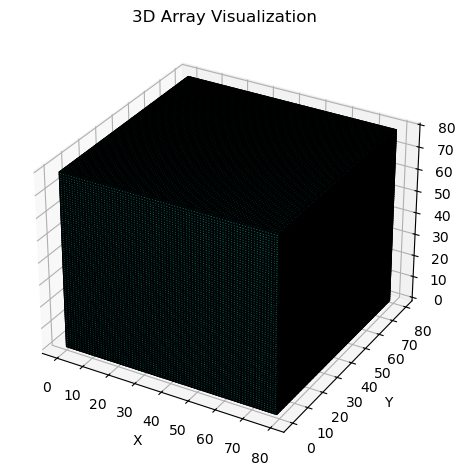

In [29]:
free_energy = calculate_free_energy_3d(all_positions)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the voxels using voxels function
ax.voxels(free_energy, facecolors='cyan', edgecolor='k', alpha=0.5)

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Array Visualization')
plt.tight_layout()
plt.show()